# <span style="color:red"> **LSN - Esercitazione 02**
### <span style="color:green"> 13.03.2025
#### <span style="color:green"> Lucrezia Bioni (13655A)

Note:
#### Esercizio 02.1: 
- provare a fare importance sampling con una p(x) con una funzione molto diversa dall'integranda
- capire come mai errore oscilla così: errore nel codice?

#### Esercizio 02.2:
- fare punto 1
- fare punto 2


## <span style="color:blue">**Esercizio 02.1**

L'esercizio consiste nel calcolo del seguente integrale monodimensionale tramite metodo Monte Carlo:
$$I := \int_0^1 \frac{\pi}{2}\cos(\pi x/2) dx = 1$$

Inizialmente, si è effettuata una stima dell'integrale tramite metodo della media, con un **campionamento uniforme dell'intervallo [0,1)**. In particolare, si valuta l'integranda $f(x)$ nei punti del campionamento, e si ottiene una stima dell'integrale facendone la media:
$$I \approx \frac {1}{N} \sum_{i=1} ^N f(x_i) $$
Tuttavia, tale scelta di distribuzione di probabilità non è la migliore: infatti, si può ridurre significativamente l'incertezza sul risultato ottenuto ricorrendo a una distribuzione di probabilità che sia più simile all'integranda, al fine di campionare con più probabilità solo le zone effettivamente rilevanti, ovvero dove l'integranda assume valori maggiori. Questa è proprio l'idea alla base del metodo dell'**Importance Sampling**, che è stato utilizzato per fare una seconda stima dell'integrale. In particolare, si fattorizza l'integranda $f(x)$ nel prodotto $g(x) p(x)$, con $g(x):= \frac{f(x)}{p(x)}$, e si campiona $g(x)$ in punti distribuiti secondo $p(x)$. Per la stima di $I$, si è scelto come $p(x)$ lo sviluppo di Taylor in $1$ di $f(x)$, ovvero, dopo opportuna normalizzazione, $p(x)=2(1-x)$; dunque, si è campionata la funzione
$$g(x)= \frac{\pi}{4} \frac{\cos(\pi x / 2)}{(1-x)}$$
in punti $x$ distribuiti secondo $p(x)$. Per ottenere tali valori di $x$, si è utilizzato il metodo dell'inversione: ottenuta la cumulativa $F(x)=:y$ di $p(x)$, la si inverte, e si trovano i valori di $x$ campionando $y$ distribuiti uniformemente in $[0,1)$:
$$F(x) = \int_0^x p(x') dx' = 2x -  x^2 =: y \quad \implies \quad x = \sqrt{1-y} \, \, \text{con}  \,\, y \in [0,1)$$$$$$$$$$

In entrambi i casi, si sono effettuati $M=10^5$ lanci, suddivisi in $N=100$ blocchi, e si sono calcolate le incertezze tramite data blocking.

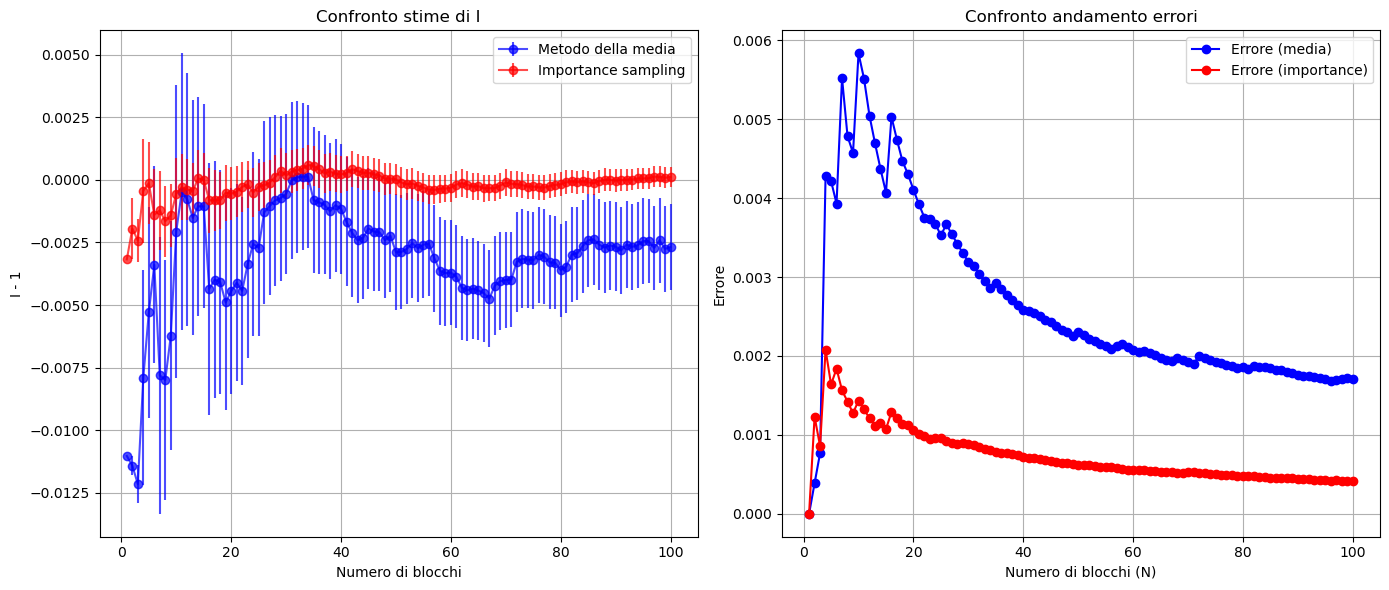

In [2]:
import matplotlib.pyplot as plt
import numpy as np

data_media = np.loadtxt("02.1/data_media.dat")
data_importance = np.loadtxt("02.1/data_importance.dat")

x_media = data_media[:, 0]
y_media = data_media[:, 2]
err_media = data_media[:, 3]

x_imp = data_importance[:, 0]
y_imp = data_importance[:, 2]
err_imp = data_importance[:, 3]

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.errorbar(x_media, y_media, yerr=err_media, fmt='bo-', label="Metodo della media", alpha=0.7)
plt.errorbar(x_imp, y_imp, yerr=err_imp, fmt='ro-', label="Importance sampling", alpha=0.7)
plt.xlabel("Numero di blocchi")
plt.ylabel("I - 1")
plt.title("Confronto stime di I")
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(x_media, err_media, 'bo-', label="Errore (media)")
plt.plot(x_imp, err_imp, 'ro-', label="Errore (importance)")
plt.xlabel("Numero di blocchi (N)")
plt.ylabel("Errore")
plt.title("Confronto andamento errori")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

Si osserva che, come atteso, tramite Importance Sampling si verifica una significativa riduzione dell’errore statistico, di circa un ordine di grandezza, rispetto al metodo della media. Ciò è legato a una scelta più efficiente della densità di probabilità, che concentra il campionamento nelle regioni in cui l’integranda contribuisce maggiormente al risultato; in questo modo, dunque, si riducono le fluttuazioni statistiche. Nonostante ciò, entrambi i metodi forniscono risultati compatibili entro $2\sigma$ dal valore atteso. L’andamento dell’errore segue $\approx \frac{1}{\sqrt{N}}$​: l'aumento del numero di campioni, dunque, è cruciale per ridurre l’incertezza. L'Importance Sampling, tuttavia, si distingue per la capacità di ottenere precisione comparabile con un numero inferiore di valutazioni, ottimizzando così le risorse computazionali.

## <span style="color:blue">**Esercizio 02.2**

L'esercizio consiste in una simulazione di Random Walk (RW) in tre dimensioni, confrontando due diversi scenari: un moto su reticolo cubico discreto e uno nel continuo. \
Per il **RW su reticolo cubico**, il walker si muove lungo gli assi principali con passo unitario $a=1$. La posizione è tracciata attraverso un vettore a sei componenti che registra gli spostamenti nelle direzioni positive e negative lungo ciascun asse, ed è determinata dall'estrazione di un numero casuale uniformemente distribuito in [0,1), che - a seconda del sottointervallo in cui ricade - assegna direzione e verso allo spostamento. La distanza quadratica media è calcolata come:

\begin{equation}
r^2 = (x_+ - x_-)^2 + (y_+ - y_-)^2 + (z_+ - z_-)^2
\end{equation}

dove $x_+$, $x_-$ rappresentano rispettivamente gli spostamenti cumulativi nelle direzioni positive e negative lungo l'asse x, e analogamente per gli altri assi.

Per il **RW nel continuo**, ogni passo è determinato da una direzione casuale uniformemente distribuita nello spazio, ottenuta campionando gli angoli $\theta \in [0,\pi]$ e $\phi \in [0,2\pi]$. La posizione viene aggiornata sommando vettorialmente i contributi dei singoli passi. 

Per entrambe le simulazioni, in totale, sono stati effettuati $M = 10^4$ random walks con posizione iniziale nell'origine, organizzati in $N=10^2$ blocchi per il calcolo degli errori statistici. All'interno di ciascun blocco, si sono effettuati $L = M/N$ random walks, ciascuno lungo $N_{passi} =10^2$ passi, e si è calcolato $\sqrt{\langle |\vec{r}_N|^2 \rangle}$ per ogni $i$-esimo passo, con $i \in (0,10^2]$. Successivamente, tramite media a blocchi, si è determinato  il valore finale, per ogni $i$-esimo passo, di $\sqrt{\langle |\vec{r}_N|^2 \rangle}$, con relativa incertezza statistica.

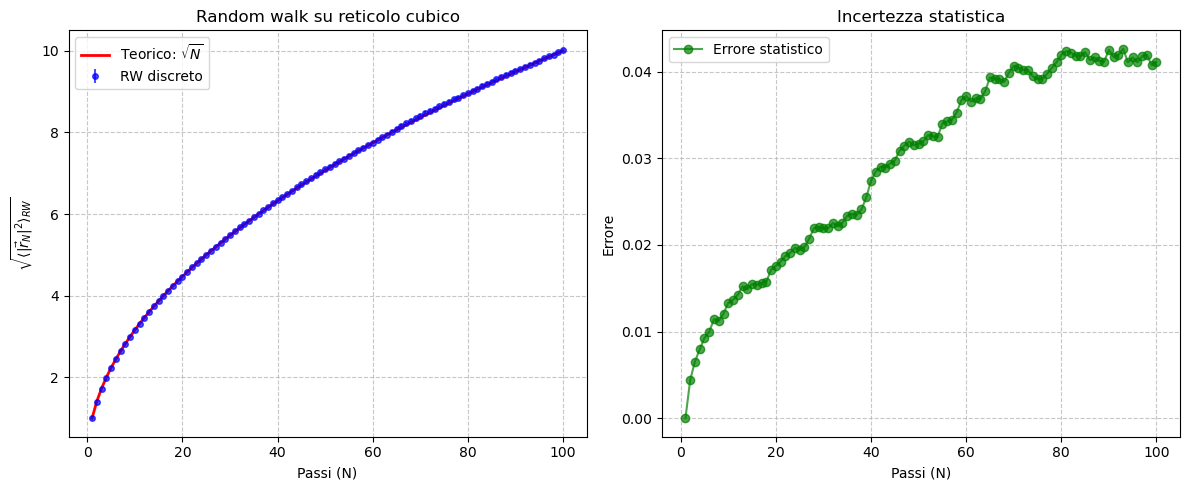

In [15]:
import matplotlib.pyplot as plt
import numpy as np

data_discreto = np.loadtxt("02.2/RW_discreto.dat")
x_discreto = data_discreto[:, 0]
y_discreto = data_discreto[:, 1]
err_discreto = data_discreto[:, 2]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)

plt.errorbar(x_discreto, y_discreto, yerr=err_discreto, fmt='bo', label="RW discreto", alpha=0.7, markersize=4)
plt.plot(x_discreto, np.sqrt(x_discreto), 'r', label=r"Teorico: $\sqrt{N}$", linewidth=2)

plt.xlabel("Passi (N)")
plt.ylabel(r"$\sqrt{\langle |\vec{r}_N|^2 \rangle_{RW}}$")
plt.title("Random walk su reticolo cubico")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
plt.plot(x_discreto, err_discreto, 'og-', label="Errore statistico", alpha=0.7)
plt.xlabel("Passi (N)")
plt.ylabel("Errore")
plt.title("Incertezza statistica")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

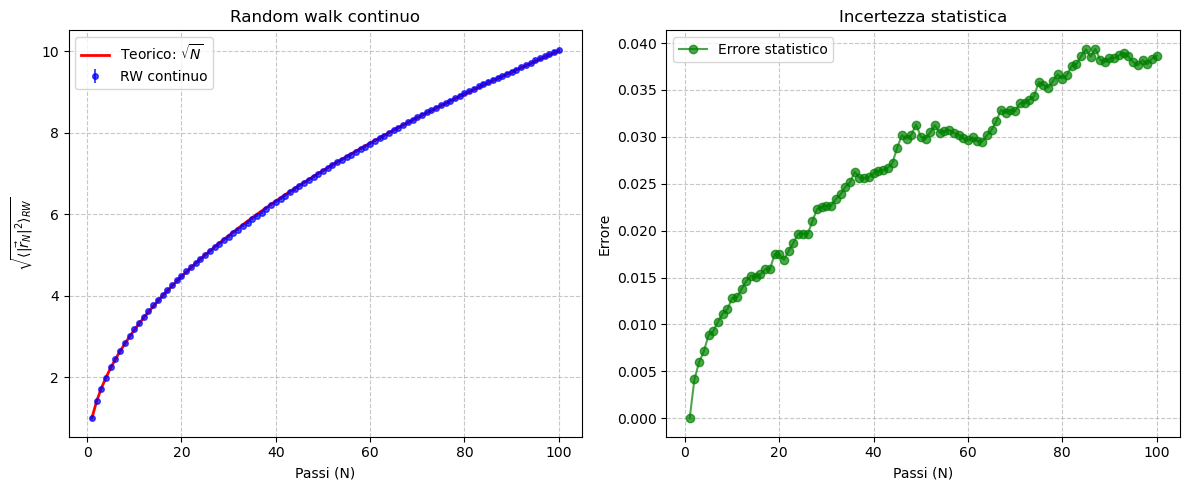

In [14]:
import matplotlib.pyplot as plt
import numpy as np

data_continuo = np.loadtxt("02.2/RW_continuo.dat")
x_continuo = data_continuo[:, 0]
y_continuo = data_continuo[:, 1]
err_continuo = data_continuo[:, 2]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)

plt.errorbar(x_continuo, y_continuo, yerr=err_continuo, fmt='bo', label="RW continuo", alpha=0.7, markersize=4)
plt.plot(x_continuo, np.sqrt(x_continuo), 'r', label=r"Teorico: $\sqrt{N}$", linewidth=2)

plt.xlabel("Passi (N)")
plt.ylabel(r"$\sqrt{\langle |\vec{r}_N|^2 \rangle_{RW}}$")
plt.title("Random walk continuo")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
plt.plot(x_continuo, err_continuo, 'og-', label="Errore statistico", alpha=0.7)
plt.xlabel("Passi (N)")
plt.ylabel("Errore")
plt.title("Incertezza statistica")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Si può dimostrare che un RW soddisfa l'equazione di diffusione, ed effettivamente i risultati ottenuti seguono entrambi un andamento diffusivo: $f(N)=k\sqrt{N}$, con due valori di $k$ molto simili tra loro, e $\approx 1$. è bene sottolineare che l'equazione soddisfatta è un'equazione differenziale **stocastica**: si ottengono, dunque, probabilità statistiche. Si osserva, inoltre, che anche l'errore cresce con il numero di passi, perché 


Il modello del Random Walk (RW) può essere dimostrato soddisfare l'equazione di diffusione, e i risultati ottenuti confermano effettivamente per entrambi i casi (reticolo cubico e continuo) un andamento diffusivo caratterizzato dalla relazione $f(N) = k\sqrt{N}$. I valori del coefficiente $k$ risultano molto simili tra loro e prossimi all'unità, in accordo con le previsioni teoriche per moto browniano in tre dimensioni.

È importante sottolineare come l'equazione soddisfatta sia un'equazione differenziale \textbf{stocastica}, il che implica che i risultati ottenuti rappresentano probabilità statistiche e non determinismi assoluti. L'analisi mostra inoltre che l'errore statistico cresce con il numero di passi compiuti, comportamento che può essere compreso considerando la natura cumulativa del processo.

Questa crescita dell'incertezza riflette il fatto che, aumentando il numero di passi, le traiettorie possibili divergono progressivamente, portando a una maggiore dispersione delle distanze finali rispetto al punto di origine. Tuttavia, la relazione fondamentale $\sqrt{\langle r^2 \rangle} \propto \sqrt{N}$ rimane ben verificata, confermando la validità dell'approccio numerico adottato e la corretta implementazione dell'algoritmo di simulazione.